# Task 3 — Demand Forecasting with Feed-Forward Neural Network

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import product

import keras
from keras import models, layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make scripts/ importable
path = os.getcwd()
while ".git" not in os.listdir(path):
    path = os.path.dirname(path)
os.chdir(Path(path))

from scripts.helpers.modelling import prepare_modelling

SEED = 42
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

In [2]:
# Make scripts/ importable
path = os.getcwd()
while ".git" not in os.listdir(path):
    path = os.path.dirname(path)
ROOT_DIR = Path(path)
os.chdir(ROOT_DIR)

In [10]:
from scripts.helpers.modelling import prepare_modelling

df = prepare_modelling(resolution=6, freq='4h')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 132756 entries, 0 to 132755
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   h3_id                 132756 non-null  string        
 1   time_bucket           132756 non-null  datetime64[us]
 2   trip_count            132756 non-null  int64         
 3   is_weekend            132756 non-null  bool          
 4   is_holiday            132756 non-null  bool          
 5   hour_sin              132756 non-null  Float64       
 6   hour_cos              132756 non-null  Float64       
 7   day_of_week_sin       132756 non-null  Float64       
 8   day_of_week_cos       132756 non-null  Float64       
 9   month_sin             132756 non-null  Float64       
 10  month_cos             132756 non-null  Float64       
 11  temperature_2m        132756 non-null  float64       
 12  apparent_temperature  132756 non-null  float64       
 13  precipitat

#### Data & feature preparation

Target — `log1p(trip_count)`. Demand is a heavily zero-inflated, right-skewed count, so the log scale stabilises.

Spatial information — one-hot hexagon id => Binary cols (0/1).

Split — random 50 / 20 / 30. Rows are shuffled.

**For further comments look into the SVM notebook, since assumptions are set to be highly comparable.**

In [11]:
# Prediction-Target: log1p-transformed trip count (invert with np.expm1 for interpretable metrics)
y = np.log1p(df['trip_count'])

drop_cols = ['h3_id', 'time_bucket', 'trip_count']

# Spatial encoding: one-hot hexagon id — gives binary column for each cell
hex_ohe = pd.get_dummies(df['h3_id'], prefix='hex', dtype=float)

# Add the one-hot hexagon encoding binary features as a column to the dataframe
x = pd.concat(
    [df.drop(columns=drop_cols), hex_ohe],
    axis=1,
).astype(float)

print(f"Feature matrix: {x.shape[0]:,} rows × {x.shape[1]} features")

Feature matrix: 132,756 rows × 50 features


In [12]:
# Random 50 / 20 / 30 split — mirrors the SVM notebook for a fair comparison
train_idx, temp_idx = train_test_split(df.index, train_size=0.50, random_state=SEED, shuffle=True)
val_idx,   test_idx = train_test_split(temp_idx, train_size=0.40, random_state=SEED, shuffle=True)

x_train, y_train = x.loc[train_idx], y.loc[train_idx]
x_val,   y_val   = x.loc[val_idx],   y.loc[val_idx]
x_test,  y_test  = x.loc[test_idx],  y.loc[test_idx]

print(f"train {len(x_train):>7,}  ({len(x_train)/len(df):.0%})")
print(f"val   {len(x_val):>7,}  ({len(x_val)/len(df):.0%})")
print(f"test  {len(x_test):>7,}  ({len(x_test)/len(df):.0%})")

train  66,378  (50%)
val    26,551  (20%)
test   39,827  (30%)


StandardScaler normalises all features to zero mean and unit variance,
ensuring no single feature dominates the gradient updates due to its scale

In [13]:
# Fit scaler on train only, then transform all splits
scaler = StandardScaler()

X_train_s = scaler.fit_transform(x_train)
X_val_s   = scaler.transform(x_val)
X_test_s  = scaler.transform(x_test)

INPUT_DIM = X_train_s.shape[1]
print(f"Input dim: {INPUT_DIM}")

Input dim: 50


#### Model architecture

A fully-connected Keras Sequential model with:
- configurable depth, width, and activation
- BatchNormalization after each hidden layer
- Dropout for regularisation
- a single linear output neuron (predicting log1p demand)

In [14]:
def build_model(hidden_dims, dropout=0.2, activation='relu', lr=1e-3, optimizer='adam'):
    """Build and compile a Keras Sequential FFNN for demand regression."""
    opt = keras.optimizers.Adam(lr) if optimizer == 'adam' else keras.optimizers.SGD(lr)

    model = models.Sequential()
    model.add(layers.Input(shape=(INPUT_DIM,)))
    for h in hidden_dims:
        model.add(layers.Dense(h))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation(activation))
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1))  # linear output for regression

    model.compile(optimizer=opt, loss='mse')
    return model

# Quick sanity check
# build_model([32, 16]).summary()

#### Hyperparameter grid search

| Parameter | Values tried |
|---|---|
| hidden layer sizes | `[128,64]`, `[256,128]`, `[256,128,64]` |
| dropout | `0.1`, `0.2`, `0.3` |
| learning rate | `0.1`, `0.01`, `0.001` |
| optimizer | `sgd`, `adam` |

Models are trained on `train` and scored on `val`. The best combination is then
retrained on `train+val` (Section 5).

> **Runtime note:** the grid runs 3×3×3×2 = 54 fits. Reduce `epochs` or narrow the grid
> if iteration speed matters.

In [15]:
# ── Hyperparameter grid ────────────────────────────────────────────────────────
HIDDEN_CONFIGS = [[128, 64], [256, 128], [256, 128, 64]]
DROPOUTS       = [0.1, 0.2]
LRS            = [0.1, 0.01, 0.001]
OPTIMIZERS     = ['sgd', 'adam']
# ──────────────────────────────────────────────────────────────────────────────

best_val_mae, best_config = np.inf, None
grid_results = []

es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)

for hidden, drop, lr, opt in product(HIDDEN_CONFIGS, DROPOUTS, LRS, OPTIMIZERS):
    m = build_model(hidden, dropout=drop, lr=lr, optimizer=opt)
    m.fit(
        X_train_s, y_train.values,
        validation_data=(X_val_s, y_val.values),
        epochs=100, batch_size=1024,
        callbacks=[es], verbose=0,
    )
    pred = np.expm1(m.predict(X_val_s, verbose=0).squeeze())
    val_mae = mean_absolute_error(np.expm1(y_val.values), pred)
    grid_results.append({'hidden': hidden, 'dropout': drop, 'lr': lr,
                         'optimizer': opt, 'val_MAE': round(val_mae, 3)})
    print(f"hidden={hidden}  drop={drop}  lr={lr}  opt={opt}  →  val MAE={val_mae:.3f}")
    if val_mae < best_val_mae:
        best_val_mae, best_config = val_mae, {'hidden': hidden, 'dropout': drop, 'lr': lr, 'optimizer': opt}

grid_df = pd.DataFrame(grid_results).sort_values('val_MAE')
print(f"\nBest config: {best_config}  →  val MAE={best_val_mae:.3f}")
grid_df

hidden=[128, 64]  drop=0.1  lr=0.1  opt=sgd  →  val MAE=11.976
hidden=[128, 64]  drop=0.1  lr=0.1  opt=adam  →  val MAE=534200.747
hidden=[128, 64]  drop=0.1  lr=0.01  opt=sgd  →  val MAE=40.936
hidden=[128, 64]  drop=0.1  lr=0.01  opt=adam  →  val MAE=272.493
hidden=[128, 64]  drop=0.1  lr=0.001  opt=sgd  →  val MAE=44.320
hidden=[128, 64]  drop=0.1  lr=0.001  opt=adam  →  val MAE=38.341
hidden=[128, 64]  drop=0.2  lr=0.1  opt=sgd  →  val MAE=31.226
hidden=[128, 64]  drop=0.2  lr=0.1  opt=adam  →  val MAE=56560636.086
hidden=[128, 64]  drop=0.2  lr=0.01  opt=sgd  →  val MAE=38.971
hidden=[128, 64]  drop=0.2  lr=0.01  opt=adam  →  val MAE=58.209
hidden=[128, 64]  drop=0.2  lr=0.001  opt=sgd  →  val MAE=45.017
hidden=[128, 64]  drop=0.2  lr=0.001  opt=adam  →  val MAE=39.912
hidden=[128, 64]  drop=0.3  lr=0.1  opt=sgd  →  val MAE=26.769
hidden=[128, 64]  drop=0.3  lr=0.1  opt=adam  →  val MAE=50069.649
hidden=[128, 64]  drop=0.3  lr=0.01  opt=sgd  →  val MAE=40.594
hidden=[128, 64]  dro

,hidden,dropout,lr,optimizer,val_MAE
0,"[128, 64]",0.1,0.100,sgd,1.197600e+01
12,"[128, 64]",0.3,0.100,sgd,2.676900e+01
42,"[256, 128, 64]",0.2,0.100,sgd,3.100700e+01
6,"[128, 64]",0.2,0.100,sgd,3.122600e+01
24,"[256, 128]",0.2,0.100,sgd,3.438200e+01
17,"[128, 64]",0.3,0.001,adam,3.804900e+01
5,"[128, 64]",0.1,0.001,adam,3.834100e+01
8,"[128, 64]",0.2,0.010,sgd,3.897100e+01
47,"[256, 128, 64]",0.2,0.001,adam,3.922400e+01
53,"[256, 128, 64]",0.3,0.001,adam,3.961400e+01


#### Activation function comparison

Using the best hyperparameters from the grid, we train one model per activation function
and compare their training loss curves. Architecture and optimizer are held fixed.

    RELU  →  val MAE=11.788
    TANH  →  val MAE=33.785
 SIGMOID  →  val MAE=44.816


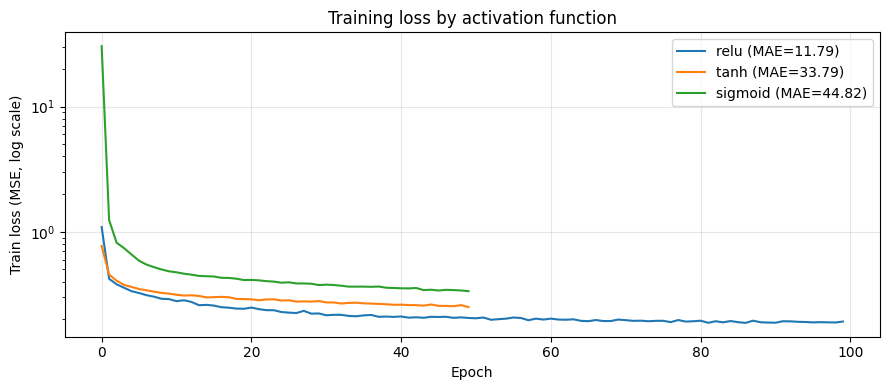

In [19]:
BEST_HIDDEN  = best_config['hidden']
BEST_DROPOUT = best_config['dropout']
BEST_LR      = best_config['lr']
BEST_OPT     = best_config['optimizer']

ACTIVATIONS = ['relu', 'tanh', 'sigmoid']
act_results = {}
es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

for act_name in ACTIVATIONS:
    m = build_model(BEST_HIDDEN, dropout=BEST_DROPOUT, activation=act_name,
                    lr=BEST_LR, optimizer=BEST_OPT)
    hist = m.fit(
        X_train_s, y_train.values,
        validation_data=(X_val_s, y_val.values),
        epochs=100, batch_size=1024,
        callbacks=[es], verbose=0,
    )
    pred = np.expm1(m.predict(X_val_s, verbose=0).squeeze())
    val_mae = mean_absolute_error(np.expm1(y_val.values), pred)
    act_results[act_name] = {'losses': hist.history['loss'], 'val_MAE': val_mae}
    print(f"{act_name.upper():>8}  →  val MAE={val_mae:.3f}")

fig, ax = plt.subplots(figsize=(9, 4))
for act_name, res in act_results.items():
    ax.plot(res['losses'], label=f"{act_name} (MAE={res['val_MAE']:.2f})")
ax.set_xlabel('Epoch')
ax.set_ylabel('Train loss (MSE, log scale)')
ax.set_yscale('log')
ax.set_title('Training loss by activation function')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()